<div class="alert alert-success"><h1>Building a Convolutional Neural Network in Python using Keras</h1></div>

Convolutional Neural Networks (CNNs) are a powerful class of deep neural networks primarily used for processing image data. CNNs have proven extremely effective in image classification, object detection, and facial recognition tasks. In this tutorial, we'll build a CNN using Keras and TensorFlow to classify images from the CIFAR-10 dataset into 10 distinct categories.

## Learning Objectives
By the end of this tutorial, you will:
+ Understand the basics of CNNs and their architecture.
+ Learn how to preprocess image data for deep learning.
+ Build a simple CNN using Keras and TensorFlow.
+ Train and evaluate the CNN model.

## Prerequisites
Before we begin, ensure you have:

+ Basic knowledge of Python programming (variables, functions, loops).
+ Understanding of fundamental machine learning concepts.
+ Python environment (version 3.x) with `tensorflow`, `keras`, and `matplotlib` installed.

<div class="alert alert-info"><b>Note:</b> For further insights into deep learning and model building with Keras and TensorFlow, consider exploring the LinkedIn Learning course <b>"Deep Learning with Python: Foundations"</b>.</div>

<div class="alert alert-success"><h2>1. Import and Preprocess the Data</h2></div>

Let's start by importing the data and verifying that the shape is as expected.

In [ ]:
from tensorflow import keras
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()
print('Training data shape:', train_images.shape)
print('Test data shape:', test_images.shape)


I0000 00:00:1785062555.175339   19715 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


The **CIFAR-10** dataset is a well-known benchmark dataset commonly used to evaluate the performance of computer vision models, particularly convolutional neural networks (CNNs). It consists of 60,000 color images, each of dimensions 32 x 32 pixels with 3 color channels (RGB), divided into:
+ 50,000 images for training.
+ 10,000 images for testing (evaluation).

Each image is assigned exactly one of ten distinct classes representing common objects - (0) Airplane, (1) Automobile, (2) Bird, (3) Cat, (4) Deer, (5) Dog, (6) Frog, (7) Horse, (8) Ship, and (9) Truck.

Let's preview the first 10 images in the training set to get a sense of what they look like. 

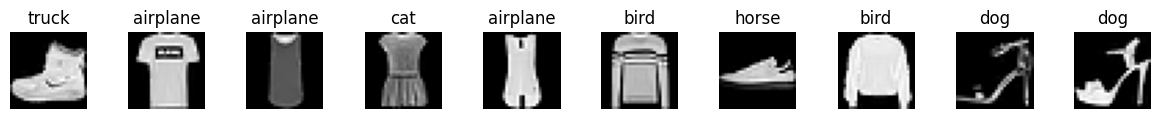

In [9]:
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 10, figsize = (15, 1))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(class_names[train_labels[i]])
    ax.axis('off')
plt.show()

As you can see, the images are very low resolution and somewhat difficult to make out. They are 32 x 32 pixels in dimension. They weren't necessarily designed to be viewed on a high-resolution screen. However, we can tell what each image is by looking at the label.

Pixel values in images range from 0 to 255. Deep learning models (such as CNNs) perform better when input values are scaled to a smaller range, typically between 0 and 1. To accommodate this, we convert the data type of the image pixels to float32 and normalize the values to fall within 0 and 1 by dividing them by 255.

In [10]:
train_images = train_images / 255.0
test_images = test_images / 255.0

For labels, we'll use one-hot encoding. Each integer label (0-9) is converted to a binary vector with one "hot" (1) position indicating the class.

In [11]:
num_classes = 10
train_labels = keras.utils.to_categorical(train_labels, num_classes)
test_labels = keras.utils.to_categorical(test_labels, num_classes)


Now, `train_labels` and `test_labels` are matrices of shape (50000, 10) and (10000, 10), respectively.